In [32]:
import numpy as np
import os, pickle
from astropy.coordinates import SkyCoord
from gammapy.modeling.models import (
PointSpatialModel, DiskSpatialModel,
PowerLawSpectralModel, 
LogParabolaSpectralModel,
ConstantTemporalModel, SkyModel, Models)
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from gammapy.visualization import colormap_hess
from scipy.stats import poisson, norm

import copy

In [2]:
input_file = "/fefs/aswg/workspace/abelardo.moralejo/test_UL_juan/S240615dg_stereo_E_0.6_20.0.pkl"

In [3]:
with open(input_file, "rb") as file:
    dataset, excess_estimator, ts_estimator, prob_gw, data_ligo_hp, mask_threshold = pickle.load(file)

In [4]:
dataset

In [5]:
excess_estimator

In [40]:
#
# Set up the excess estimator: correlation radius and "n_sigma_ul"
# n_sigma_ul chosen in order to get a one-sided upper limit of a given confidence level
#
excess_estimator.correlation_radius = 0.1 * u.deg  # a.k.a. top-hat integration

confidence_level = 0.95 # ONE-SIDED, integral(-inf, UL) = 0.95
excess_estimator.n_sigma_ul = norm.ppf(confidence_level)

In [73]:
#
# We create a point-like source with a power-law spectrum, at the central position (taken from ts_estimator)
#

dec_sim = ts_estimator.model.parameters['lat_0'].value # deg
ra_sim = ts_estimator.model.parameters['lon_0'].value # deg

tested_amplitude = 1e-11 # 1e-10 # s-1 cm-2 TeV-1 @ 1 TeV

sim_coord = SkyCoord(ra=ra_sim, dec=dec_sim, unit=u.deg, frame="icrs")

model_source = Models([SkyModel(spatial_model = PointSpatialModel.from_position(sim_coord),
                                spectral_model = PowerLawSpectralModel(index=2, 
                                                                       amplitude=f"{tested_amplitude} cm-2 s-1 TeV-1", 
                                                                       reference="1 TeV"),
                                temporal_model = ConstantTemporalModel(),
                                name="model-simulated",
                               )])
dataset.models = model_source

In [42]:
#
# TESTS TESTS TESTS
#
# Let's reduce the background:
#dataset.background.data /= 10
#dataset.background.data /= 10000000 # make it completely negligible (for tests)

# Or increase it:
# dataset.background.data *= 100


In [43]:
#
#
# Create fake dataset
#
#

dataset.fake()

#
#

In [44]:
# For the fit we have to remove from the dataset the model with which we generated the fake observation, OTHERWISE 
# IT WOULD BE CONSIDERED PART OF THE MODEL, AND THEN THE FITTED EXCESS WOULD BE ~ZERO IN AVERAGE!!
dataset_observed = copy.deepcopy(dataset)
dataset_observed.models = None

<WCSAxes: >

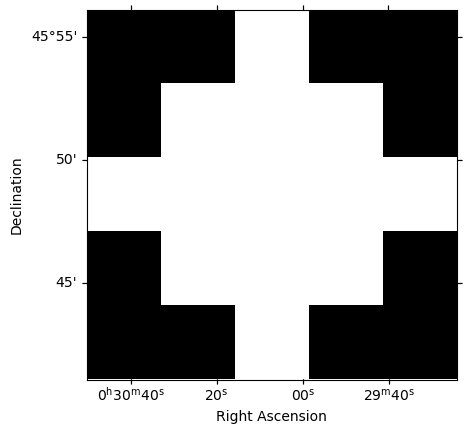

In [45]:
# A funny top-hat indeed, finer binning should definitely be considered:
excess_estimator.estimate_kernel(dataset).plot()

In [46]:
#
# Run the map calculation
#
result_observed = excess_estimator.run(dataset=dataset_observed)

In [47]:
result_observed.flux.data.shape

(1, 71, 71)

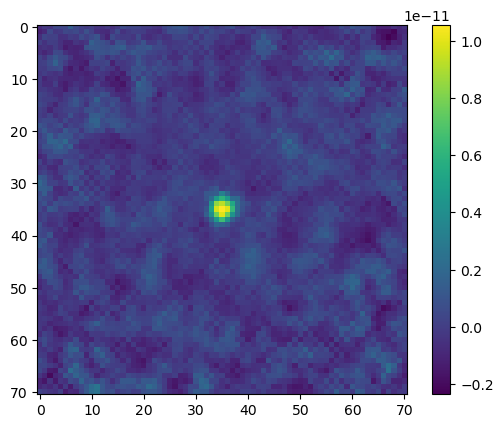

In [48]:
plt.imshow(result_observed.flux.data[0]) # , norm=LogNorm())
plt.colorbar()

In [49]:
true_flux_integral = model_source[0].spectral_model.integral(excess_estimator.energy_edges[0],
                                                             excess_estimator.energy_edges[-1])
true_flux_integral

<Quantity 1.61666667e-11 1 / (s cm2)>

In [50]:
#
# THIS IS PRESUMABLY THE PSF CONTAINMENT WITHIN THE CORRELATION RADIUS, FOR THE ASSUMED SPECTRUM AND E-RANGE:
#
result_observed.flux.data[0, 35, 35]/(u.cm**2)/u.s / true_flux_integral


<Quantity 0.65346203>

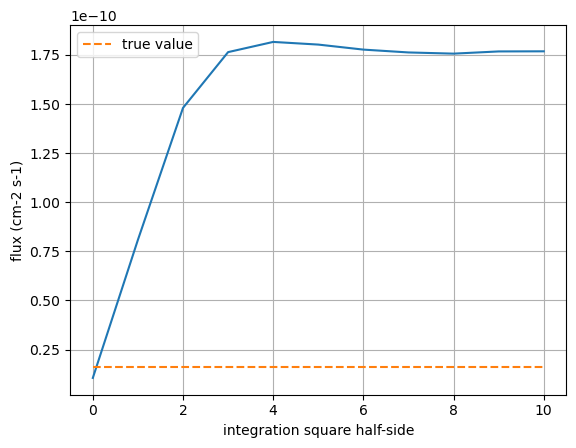

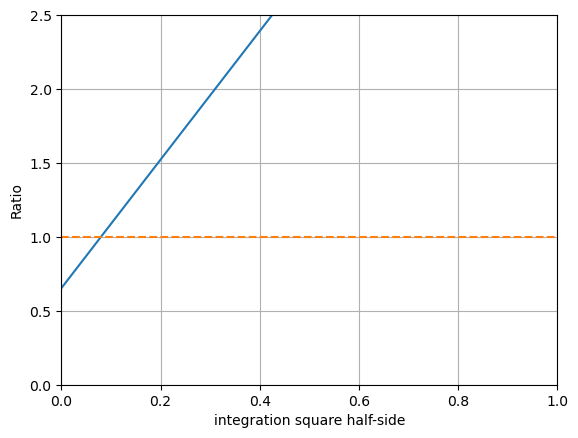

In [51]:
# 
# JUST A TEST: IT DOES NOT MAKE SENSE TO ADD UP THE FLUXES IN THESE BINS, THEY ARE VERY CORRELATED, AND 
# EACH ONE CONTAINS THE FLUX IN A CIRCLE OF RADIUS correlation_radius AROUND IT
#
#
kkx = np.linspace(0, 10, 11)
kky = np.zeros_like(kkx) 
for k in range(11):
    kky[k] = np.nansum(result_observed.flux.data[0, 35-k:35+1+k, 35-k:35+1+k])
    ## print(k, ':', np.sum(np.isnan(result_observed.flux.data[0, 35-k:35+1+k, 35-k:35+1+k])), 'nans')
plt.plot(kkx, kky)

plt.plot([0, 10], [true_flux_integral.to_value(), true_flux_integral.to_value()], '--', label='true value')
plt.legend()
#plt.ylim(0, 1.1*true_flux_integral.to_value())
plt.ylabel('flux (cm-2 s-1)')
plt.xlabel('integration square half-side')
plt.grid()
plt.show()

plt.plot(kkx, kky/true_flux_integral.to_value())
plt.plot([0, 10], [1, 1], '--', label='true value')
plt.ylabel('Ratio')
plt.xlabel('integration square half-side')
plt.ylim(0, 2.5)
plt.xlim(0, 1)

plt.grid()
plt.show()


In [52]:
result_observed.available_quantities

['npred',
 'npred_excess',
 'counts',
 'ts',
 'sqrt_ts',
 'norm',
 'norm_err',
 'norm_ul']

In [53]:
result_observed.norm.data.shape

(1, 71, 71)

In [54]:
result_observed.norm.data[0, 35, 35]
# norm * the flux in the excess map estimator spectral model equals the result, makes sense

np.float32(6.5346203)

In [55]:
result_observed.norm_err.data[0, 35, 35]

np.float32(0.5625932)

In [56]:
result_observed.norm_ul.data[0, 35, 35]

np.float64(7.493392958736804)

In [23]:
# We can correct the UL and the best-fit (for the PSF containment) by the average factor
# Let's compute it with 100 toy simulations:
num_simulations = 100
computed_flux = np.zeros(num_simulations)

flux_factor = 100
model_source[0].spectral_model.amplitude.value *= flux_factor  # to make it more accurate

for k in range(num_simulations):
    dataset.models = model_source
    dataset.fake()
    dataset.models = None
    tmp_result = excess_estimator.run(dataset)
    computed_flux[k] = tmp_result.flux.data[0, 35, 35]


model_source[0].spectral_model.amplitude.value /= flux_factor



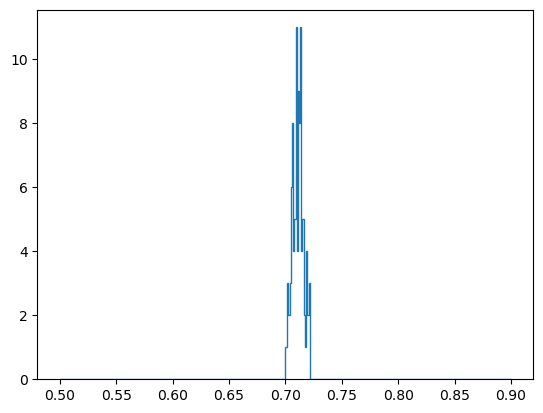

PSF containment: 0.710887095336914

NOTE THAT THIS FACTOR WILL ALSO AUTOMATICALLY CORRECT FOR ANY E-MIGRATION ISSUE, NOT JUST PSF!

THE SAME FACTOR SHOULD BE APPLIED TO OBTAIN THE CORRECT FLUX (OR FLUX UL) MAP!




In [108]:
plt.hist(computed_flux/flux_factor/true_flux_integral.to_value(), bins=400, range=(0.5, 0.9), histtype='step')
plt.show()

psf_containment = np.mean(computed_flux/flux_factor/true_flux_integral.to_value())
print('PSF containment:', psf_containment)

print("\nNOTE THAT THIS FACTOR WILL ALSO AUTOMATICALLY CORRECT FOR ANY E-MIGRATION ISSUE, NOT JUST PSF!\n")
print("THE SAME FACTOR SHOULD BE APPLIED TO OBTAIN THE CORRECT FLUX (OR FLUX UL) MAP!\n\n")

<WCSAxes: >

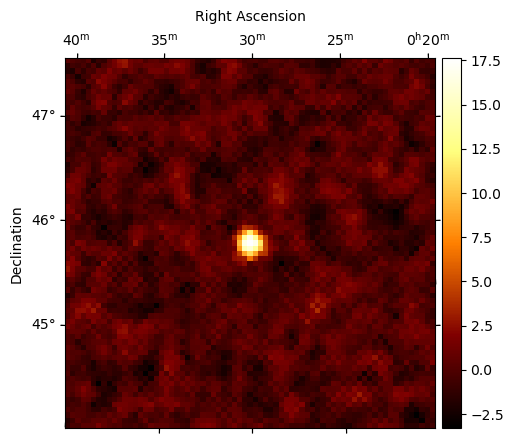

In [57]:
result_observed.sqrt_ts.plot(add_cbar=True, stretch="linear")

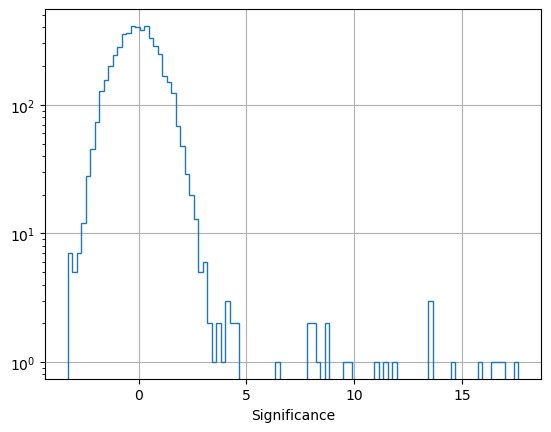

In [58]:
plt.hist(result_observed.sqrt_ts.data.flatten(), bins=100, histtype='step')
plt.xlabel('Significance')
plt.yscale('log')
plt.grid()
plt.show()
    

In [67]:
# The analytical Upper Limit with all corrections:
analytical_flux_UL = (result_observed.flux.data[0, 35, 35] *
                      result_observed.norm_ul.data[0, 35, 35] / 
                      result_observed.norm.data[0, 35, 35] / 
                      psf_containment)
print(analytical_flux_UL, 'cm-2 s-1, for point-like source')

1.7041128888242237e-11 cm-2 s-1, for point-like source


In [74]:
# Find the amplitude needed to simulate such flux:
ul_amplitude = analytical_flux_UL / (u.cm**2) / u.s / true_flux_integral * tested_amplitude
ul_amplitude

<Quantity 1.05409045e-11>

In [83]:
#
# Now we can simulate a source with flux equal to the analytical upper limit. We then check in what fraction of 
# the toy MC realizations the ts value (rather, *signed significance*) at the source position is larger that the 
# actually observed one
#

num_simulations = 1000
toymc_signi = np.zeros(num_simulations)

model_source[0].spectral_model.amplitude.value = ul_amplitude

for k in range(num_simulations):
    if k%10 == 0:
        print(k, '/', num_simulations) 
    dataset.models = model_source
    dataset.fake()
    dataset.models = None
    tmp_result = excess_estimator.run(dataset)
    toymc_signi[k] = tmp_result.sqrt_ts.data[0, 35, 35]



0 / 1000
10 / 1000
20 / 1000
30 / 1000
40 / 1000
50 / 1000
60 / 1000
70 / 1000
80 / 1000
90 / 1000
100 / 1000
110 / 1000
120 / 1000
130 / 1000
140 / 1000
150 / 1000
160 / 1000
170 / 1000
180 / 1000
190 / 1000
200 / 1000
210 / 1000
220 / 1000
230 / 1000
240 / 1000
250 / 1000
260 / 1000
270 / 1000
280 / 1000
290 / 1000
300 / 1000
310 / 1000
320 / 1000
330 / 1000
340 / 1000
350 / 1000
360 / 1000
370 / 1000
380 / 1000
390 / 1000
400 / 1000
410 / 1000
420 / 1000
430 / 1000
440 / 1000
450 / 1000
460 / 1000
470 / 1000
480 / 1000
490 / 1000
500 / 1000
510 / 1000
520 / 1000
530 / 1000
540 / 1000
550 / 1000
560 / 1000
570 / 1000
580 / 1000
590 / 1000
600 / 1000
610 / 1000
620 / 1000
630 / 1000
640 / 1000
650 / 1000
660 / 1000
670 / 1000
680 / 1000
690 / 1000
700 / 1000
710 / 1000
720 / 1000
730 / 1000
740 / 1000
750 / 1000
760 / 1000
770 / 1000
780 / 1000
790 / 1000
800 / 1000
810 / 1000
820 / 1000
830 / 1000
840 / 1000
850 / 1000
860 / 1000
870 / 1000
880 / 1000
890 / 1000
900 / 1000
910 / 1000

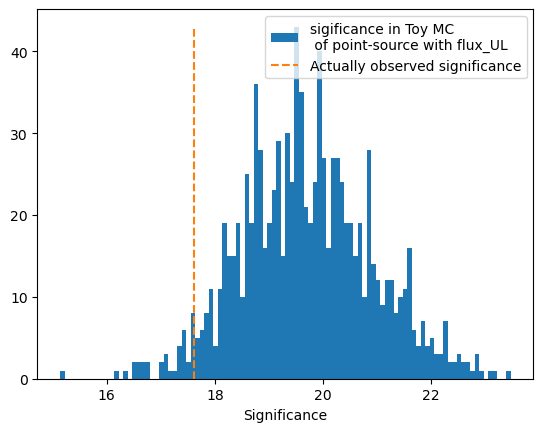

Fraction below actually observed significance: 0.038
Average significance: 19.707


In [87]:
ccts, _, _ = plt.hist(toymc_signi, bins=100, 
                      label="sigificance in Toy MC\n of point-source with flux_UL")

observed_signi = result_observed.sqrt_ts.data[0, 35, 35]
plt.plot([observed_signi, observed_signi], 
         [0, ccts.max()], '--', label="Actually observed significance")
plt.legend()
plt.xlabel('Significance')
plt.show()

print('Fraction below actually observed significance:', (toymc_signi<=observed_signi).sum() / num_simulations) 
print(f'Average significance: {toymc_signi.mean():.3f}')

In [92]:
# Significance below which one finds a fraction 1-CL of realizations:
correct_coverage_signi = np.sort(toymc_signi)[int((1 - confidence_level) * num_simulations)]
correct_coverage_signi

np.float64(17.8514063316612)

In [102]:
# Just an approximation here: at least in case of a positive signal and non-negligible background, the significance is roughly 
# proportional to the flux
signi_shift = observed_signi - correct_coverage_signi# needed shift of the distribution to get the right CL
signi_shift

np.float64(-0.24091712996654735)

In [104]:
# FLux UL with correct coverage
# This fraction indicate how well the analytical and the empirical limits agree for this particular simulated observation:
print(f'\nFlux UL with correct coverage / Analytical Flux UL: {(toymc_signi.mean()+signi_shift) / toymc_signi.mean():.3f}\n')


Flux UL with correct coverage / Analytical Flux UL: 0.988

